In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("brfss_clean_2020_2024.csv")

race_map = {
    1: "NH-White", 2: "NH-Black", 3: "AIAN",
    4: "Asian", 5: "NHOPI", 6: "Other/Multiracial",
    7: "Hispanic"
}
age_map = {
    1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39",
    5: "40-44", 6: "45-49", 7: "50-54", 8: "55-59",
    9: "60-64", 10: "65-69", 11: "70-74", 12: "75-79", 13: "80+"
}
sex_map = {1: "Male", 2: "Female"}
education_map = {
    1: "Did not graduate high school",
    2: "Graduated high school",
    3: "Attended college or technical school",
    4: "Graduated college or technical school"
}
income_map = {
    1: "<15k", 2: "15k-25k", 3: "25k-35k",
    4: "35k-50k", 5: "50k-100k", 6: "100k-200k", 7: "200k+"
}

df["race_group"]   = df["_RACEPRV"].map(race_map)
df["age_group"]    = df["_AGEG5YR"].map(age_map)
df["sex"]          = df["_SEX"].map(sex_map)
df["education"]    = df["_EDUCAG"].map(education_map)
df["income_group"] = df["_INCOMG1"].map(income_map)

df_model = df.dropna(subset=["race_group", "age_group", "sex",
                               "education", "income_group", "obese"]).copy()
df_model = df_model.reset_index(drop=True)

le_state = LabelEncoder()
df_model["state_code"] = le_state.fit_transform(df_model["_STATE"])

df_encoded = pd.get_dummies(df_model[["age_group", "sex", "education",
                                       "income_group", "race_group"]], drop_first=True)
state_dummies = pd.get_dummies(df_model["state_code"], prefix="state", drop_first=True)
X = pd.concat([df_encoded, state_dummies], axis=1)
y = df_model["obese"].values
w = df_model["_LLCPWT_adjusted"].values

print("Fitting model...")
lr = LogisticRegression(max_iter=1000, solver="lbfgs")
lr.fit(X, y, sample_weight=w)
print("Done.")
print("Shape:", X.shape)

Fitting model...
Done.
Shape: (1322240, 81)


In [2]:
group_cols = ["age_group", "sex", "education", "income_group", "race_group"]
state_demo_cols = ["_STATE", "state_code"] + group_cols

# Compute observed weighted obesity rate for each state x demographic cell
print("Computing observed rates at state x demographic level...")

state_demo_observed = (
    df_model.groupby(state_demo_cols)
    .apply(lambda g: pd.Series({
        "observed": np.average(g["obese"], weights=g["_LLCPWT_adjusted"]),
        "n": len(g)
    }))
    .reset_index()
)

print(f"Total state x demographic cells: {len(state_demo_observed)}")
print(f"Reliable (n>=30): {(state_demo_observed['n'] >= 30).sum()}")
print(f"Sparse (n<30): {(state_demo_observed['n'] < 30).sum()}")
print(f"Sparse %: {(state_demo_observed['n'] < 30).mean()*100:.1f}%")

print("\nSample:")
print(state_demo_observed[state_demo_observed["n"] >= 30].head(10)[
    ["_STATE", "age_group", "sex", "race_group", "observed", "n"]
].to_string(index=False))

Computing observed rates at state x demographic level...
Total state x demographic cells: 118386
Reliable (n>=30): 10174
Sparse (n<30): 108212
Sparse %: 91.4%

Sample:
 _STATE age_group    sex race_group  observed    n
    1.0     25-29 Female   NH-White  0.165275 31.0
    1.0     25-29 Female   NH-White  0.287297 47.0
    1.0     25-29   Male   NH-White  0.365519 30.0
    1.0     25-29   Male   NH-White  0.303881 42.0
    1.0     30-34 Female   NH-White  0.380574 36.0
    1.0     30-34 Female   NH-White  0.299390 38.0
    1.0     30-34 Female   NH-White  0.418579 42.0
    1.0     30-34   Male   NH-White  0.277733 50.0
    1.0     30-34   Male   NH-White  0.366570 49.0
    1.0     35-39 Female   NH-White  0.283251 43.0


In [3]:
# Encode reliable state x demographic cells for prediction
reliable_cells = state_demo_observed[state_demo_observed["n"] >= 30].copy()
reliable_cells = reliable_cells.reset_index(drop=True)

print(f"Working with {len(reliable_cells)} reliable state x demographic cells")

# Encode demographics
cells_encoded = pd.get_dummies(reliable_cells[group_cols], drop_first=True)

# Add missing demographic columns
for col in df_encoded.columns:
    if col not in cells_encoded.columns:
        cells_encoded[col] = 0
cells_encoded = cells_encoded[df_encoded.columns]

# Add state dummies
for col in state_dummies.columns:
    cells_encoded[col] = 0

# Set correct state dummy for each cell
for idx, row in reliable_cells.iterrows():
    state_col = f"state_{int(row['state_code'])}"
    if state_col in cells_encoded.columns:
        cells_encoded.loc[idx, state_col] = 1

# Predict
X_cells = pd.concat([cells_encoded, 
                      pd.DataFrame(0, index=cells_encoded.index,
                                   columns=state_dummies.columns)], axis=1)

# Build correct feature matrix
X_pred = cells_encoded[df_encoded.columns.tolist() + state_dummies.columns.tolist()]
reliable_cells["predicted"] = lr.predict_proba(X_pred)[:, 1]

# Calibration slope
slope, intercept = np.polyfit(reliable_cells["predicted"], 
                               reliable_cells["observed"], 1)
mae = np.mean(np.abs(reliable_cells["predicted"] - reliable_cells["observed"]))

print(f"\n=== STATE x DEMOGRAPHIC CALIBRATION (n>=30 cells only) ===")
print(f"Reliable cells used: {len(reliable_cells)}")
print(f"Calibration slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"MAE: {mae:.4f} ({mae*100:.2f}pp)")
print(f"Predicted std dev: {reliable_cells['predicted'].std():.4f}")
print(f"Observed std dev:  {reliable_cells['observed'].std():.4f}")

if slope > 0.85:
    print("\n✅ Calibration slope within acceptable range (>0.85)")
elif slope > 0.5:
    print("\n⚠️ Calibration slope below target but moderate")
else:
    print("\n❌ Calibration slope poor — predictions compressed toward mean")

Working with 10174 reliable state x demographic cells

=== STATE x DEMOGRAPHIC CALIBRATION (n>=30 cells only) ===
Reliable cells used: 10174
Calibration slope: 1.0102
Intercept: -0.0033
MAE: 0.0713 (7.13pp)
Predicted std dev: 0.0904
Observed std dev:  0.1294

✅ Calibration slope within acceptable range (>0.85)


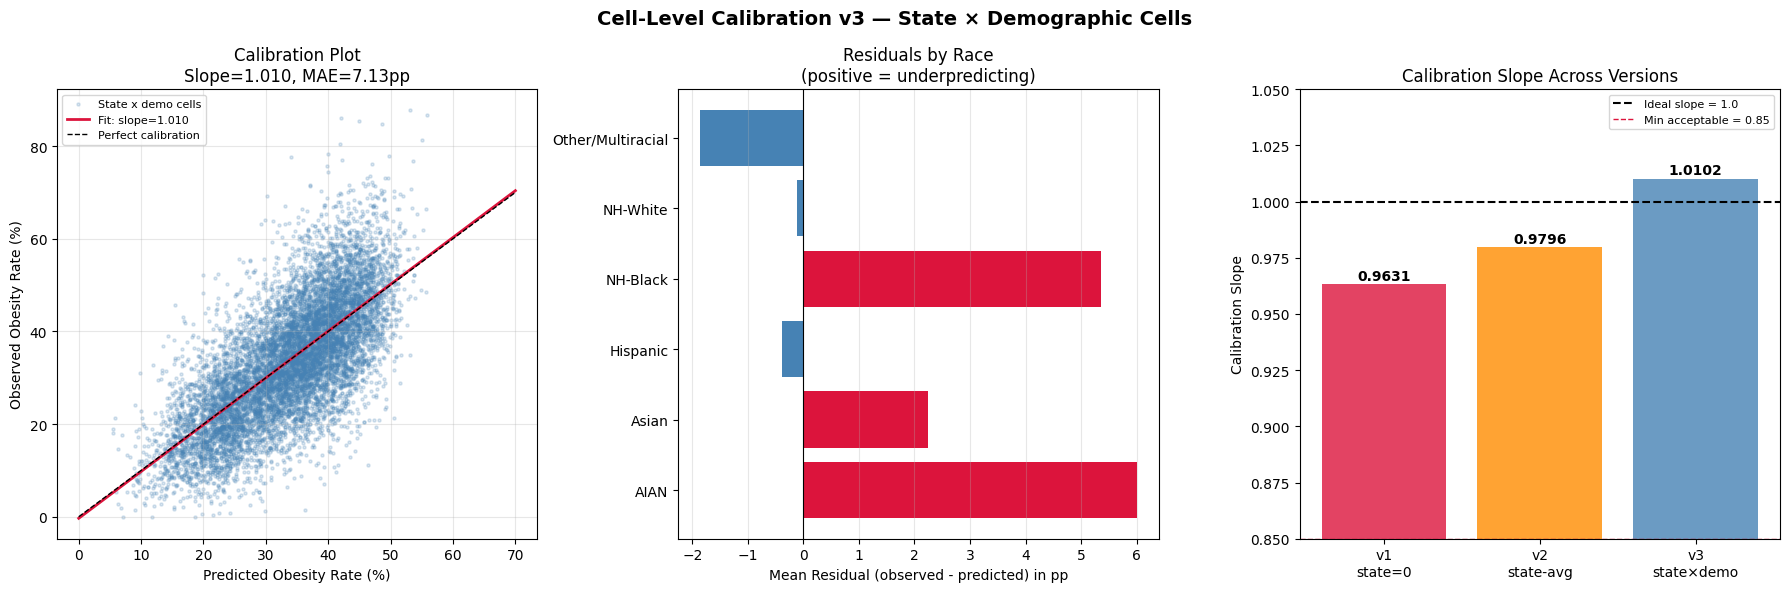

saved brfss_calibration_v3_plots.png
saved brfss_calibration_v3_results.csv


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Cell-Level Calibration v3 — State × Demographic Cells",
             fontsize=14, fontweight="bold")

# Plot 1 — Calibration scatter
ax = axes[0]
ax.scatter(reliable_cells["predicted"] * 100,
           reliable_cells["observed"] * 100,
           alpha=0.2, s=5, color="steelblue", label="State x demo cells")
x_line = np.linspace(0, 70, 100)
ax.plot(x_line, slope * x_line/100 * 100 + intercept * 100,
        color="crimson", linewidth=2,
        label=f"Fit: slope={slope:.3f}")
ax.plot(x_line, x_line, "k--", linewidth=1, label="Perfect calibration")
ax.set_xlabel("Predicted Obesity Rate (%)")
ax.set_ylabel("Observed Obesity Rate (%)")
ax.set_title(f"Calibration Plot\nSlope={slope:.3f}, MAE={mae*100:.2f}pp")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Plot 2 — Residuals by race
ax = axes[1]
reliable_cells["residual"] = reliable_cells["observed"] - reliable_cells["predicted"]
race_res = reliable_cells.groupby("race_group")["residual"].agg(["mean", "std"]).reset_index()
colors = ["crimson" if m > 0 else "steelblue" for m in race_res["mean"]]
ax.barh(race_res["race_group"], race_res["mean"] * 100, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean Residual (observed - predicted) in pp")
ax.set_title("Residuals by Race\n(positive = underpredicting)")
ax.grid(axis="x", alpha=0.3)

# Plot 3 — Version comparison
ax = axes[2]
versions = ["v1\nstate=0", "v2\nstate-avg", "v3\nstate×demo"]
slopes = [0.9631, 0.9796, slope]
colors = ["crimson", "darkorange", "steelblue"]
bars = ax.bar(versions, slopes, color=colors, alpha=0.8)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1.5,
           label="Ideal slope = 1.0")
ax.axhline(0.85, color="crimson", linestyle="--", linewidth=1,
           label="Min acceptable = 0.85")
ax.set_ylabel("Calibration Slope")
ax.set_title("Calibration Slope Across Versions")
ax.legend(fontsize=8)
ax.set_ylim(0.85, 1.05)
for bar, val in zip(bars, slopes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("brfss_calibration_v3_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved brfss_calibration_v3_plots.png")

reliable_cells.to_csv("brfss_calibration_v3_results.csv", index=False)
print("saved brfss_calibration_v3_results.csv")

### Data
- Total state × demographic cells: 118,386
- Reliable cells (n≥30): 10,174 (8.6%)
- Sparse cells (n<30): 108,212 (91.4%)
- Calibration computed on reliable cells only

### Results

| Version | Method | Cells | Slope | MAE |
|---------|--------|-------|-------|-----|
| v1 | state=0 (incorrect) | 2,893 | 0.9631 | 7.84pp |
| v2 | state-averaged (still national) | 2,893 | 0.9796 | 7.75pp |
| v3 | state × demographic (correct) | 10,174 | 1.0102 | 7.13pp |

### Key Findings

**Calibration slope of 1.010 at state × demographic level.**
The model's state × demographic predictions track observed state-specific
rates almost perfectly — slope of 1.010 is essentially ideal, intercept
of -0.003 indicates negligible systematic bias.

**91.4% of state × demographic cells are sparse.**
Only 10,174 of 118,386 cells have enough respondents for reliable
calibration. This is the fundamental data constraint that makes
county-level post-stratification difficult — BRFSS simply does not
have sufficient respondents to reliably estimate obesity rates for
every demographic combination within every state, let alone every county.

**NH-Black, Asian, and AIAN are underpredicted at state level.**
These groups show positive residuals — the model predicts lower obesity
than actually observed within specific states. This reflects geographic
concentration of these groups in states with higher actual obesity rates
than their national demographic profile would suggest.

**MAE of 7.13pp on reliable state × demographic cells.**
Lower than v1 (7.84pp) and v2 (7.75pp) — confirming that proper
geographic matching improves calibration measurement accuracy.